In [1]:
import sys;sys.path.append('../..')
from abslithist import *

In [44]:
df_fic_meta = pd.read_excel('/Users/ryan/lltk_data/corpora/canon_fiction/metadata.xls').set_index('id')
df_poe_meta = pd.read_csv('/Users/ryan/lltk_data/corpora/chadwyck_poetry/metadata.csv').set_index('id')

In [45]:
df_fic = pd.read_pickle(os.path.join(PATH_DATA,'scores','bak','data.scores.CanonFiction.pkl')).dropna()
df_poe = pd.read_pickle(os.path.join(PATH_DATA,'scores','bak','data.scores.ChadwyckPoetry.pkl')).dropna()

df_fic = df_fic.join(df_fic_meta[['year']]).assign(corpus='CanonFiction')
df_poe = df_poe.join(df_poe_meta[['year']]).assign(corpus='ChadwyckPoetry')

df_fic['genre'] = 'Fiction'
df_poe['genre'] = 'Verse'

In [122]:
df_hathi = pd.read_pickle(os.path.join(PATH_DATA,'scores','v3','data.scores.HathiEngLit.pkl')).assign(corpus='Hathi')
df_hathi['Abs-Conc.Median.median'] = df_hathi['score']
df_hathi['genre'] = df_hathi['genre'].str.replace('Poetry', 'Verse')
df_hathi.genre.value_counts()

genre
Drama      17561
Fiction    11341
Verse        439
Name: count, dtype: int64

In [128]:
# df_ecco = pd.read_pickle(os.path.join(PATH_DATA,'scores','v3','data.scores.ECCO_TCP.pkl'))
# df_ecco

In [133]:
df_poe_hathi = pd.read_csv('/Users/ryan/Downloads/poetry_yearly_summary.csv')
df_poe_hathi.query('year==1901').sort_values('termfreq')

,year,word,termfreq,correctionapplied
1750193,1901,withdraws,46,0
1758378,1901,chang,58,0
1755397,1901,glares,67,0
1751979,1901,parch,75,0
1753843,1901,livelier,77,0
...,...,...,...,...
1751465,1901,the,1693516,0
1756402,1901,",",2744057,0
1752197,1901,#DICTIONARYWORD,27376671,0
1758507,1901,#ALPHABETIC,27811762,0


In [76]:
df_essay1 = pd.read_pickle(os.path.join(PATH_DATA,'scores','v3','data.scores.HathiEssays.pkl'))
df_essay1['genre'] = 'Essay'
df_essay1['Abs-Conc.Median.median'] = df_essay1['score']

df_essay2 = pd.read_pickle(os.path.join(PATH_DATA,'scores','v3','data.scores.ECCO_TCP.pkl'))
df_essay2 = df_essay2[df_essay2.title.str.lower().str.contains('essay')]
df_essay2['genre'] = 'Essay'
df_essay2['Abs-Conc.Median.median'] = df_essay2['score']

df_essay3 = pd.read_pickle(os.path.join(PATH_DATA,'scores','v3','data.scores.EEBO_TCP.pkl'))
df_essay3 = df_essay3[df_essay3.title.str.lower().str.contains('essay')]
df_essay3['genre'] = 'Essay'
df_essay3['Abs-Conc.Median.median'] = df_essay3['score']

df_essay = pd.concat([df_essay1.assign(corpus='Hathi'), df_essay2.assign(corpus='ECCO-TCP'), df_essay3.assign(corpus='EEBO-TCP')])

In [77]:
df_bpo = pd.read_pickle(os.path.join(PATH_DATA,'scores','bak','data.scores.BPO.pkl')).assign(corpus='BPO')
df_bpo['genre'] = [x.split('/')[1] for x in df_bpo.index]
df_bpo['year'] = [int(x.split('/')[0]) for x in df_bpo.index]
df_bpo.genre.value_counts()

genre
Unknown                7518
General_Information    6747
Review                 6156
Back_Matter            5166
Poem                   4968
Correspondence         4431
Front_Matter           4126
Advertisement          3565
Fiction                3388
News                   2368
Obituary               1495
Recipe                  366
Undefined               155
Name: count, dtype: int64

In [78]:
bpo_genres = ['Review', 'Correspondence', 'News', 'Unknown', 'General_Information']

In [102]:
df = pd.concat([
    # df_bpo[df_bpo.genre.isin(bpo_genres)].assign(genre='Periodical'),
    df_fic, 
    df_poe,
    df_essay,
    # df_hathi
])
df=df.dropna(subset=['year'])
df['decade'] = df.year.astype(int) // 10 * 10


In [103]:
p9.options.figure_size = (12,6)
p9.options.dpi = 300
df.genre.value_counts()

genre
Verse      306039
Essay        7537
Fiction      1805
Name: count, dtype: int64

In [104]:
# df.genre

In [105]:
# fig = (
#     p9.ggplot(
#         df,
#         p9.aes(x='year', y='Abs-Conc.Median.median', color='genre')
#     )
#     # + p9.geom_point()
#     + p9.geom_smooth(method='loess')
#     + p9.theme_minimal()
# )
# fig

In [106]:
yearcol = 'year'
odf = get_avgs_df(df, gby=["genre", yearcol], y="Abs-Conc.Median.median")
# odf = odf.query('count >= 5')
odf

mean    stderr  count
genre year                             
Essay 0.0    -0.147105       NaN      1
      1116.0 -0.387497       NaN      1
      1167.0 -0.364368       NaN      1
      1584.0 -0.094449       NaN      1
      1597.0 -0.690910       NaN      1
...                ...       ...    ...
Verse 2000.0  0.854136  0.034418     64
      2001.0 -0.060618  0.032071    294
      2002.0  0.290078  0.059182     40
      2003.0  0.570346  0.063435     77
      2004.0  0.898551  0.073524     26

[1214 rows x 3 columns]

In [119]:
def plot_avgs_df(figdf, **labs):
    fig = (
        p9.ggplot(
            figdf,
            p9.aes(x=yearcol, y='mean', linetype='genre'),
        )
        # + p9.geom_errorbar(p9.aes(ymin='mean-stderr', ymax='mean+stderr'), width=10, alpha=0.75)
        # + p9.geom_point()
        # + p9.geom_line()
        # + p9.geom_point(p9.aes(y='mean',size='count'), alpha=.5)
        # + p9.facet_wrap('genre', scales='free_y')
        + p9.theme_minimal()
        + p9.scale_size_continuous(range=(.5, 5))
        + p9.geom_smooth(method='loess', span=0.3, alpha=0.15, size=1)
        + p9.labs(**labs)
        + p9.theme(figure_size=(12,6), dpi=300)
        + p9.scale_y_continuous(limits=(-4,4))
        + p9.scale_linetype_manual(values={'Essay':'dotted', 'Fiction':'solid', 'Verse':'dashed', 'Treatise':'dotdash', 'Sermon':'longdash', 'Periodical':'twodash'})
        # + p9.scale_y_continuous(limits=(-2,2))
    )
    return fig


In [120]:
# genres = {'Essay','Fiction', 'Verse', 'Treatise', 'Sermon', 'Periodical'}
# # genres = {'Essay','Fiction', 'Verse'}
# genres = {'Essay','Fiction', 'Verse'}
# genres = {'Essay', 'Sermon','Fiction', 'Verse'}

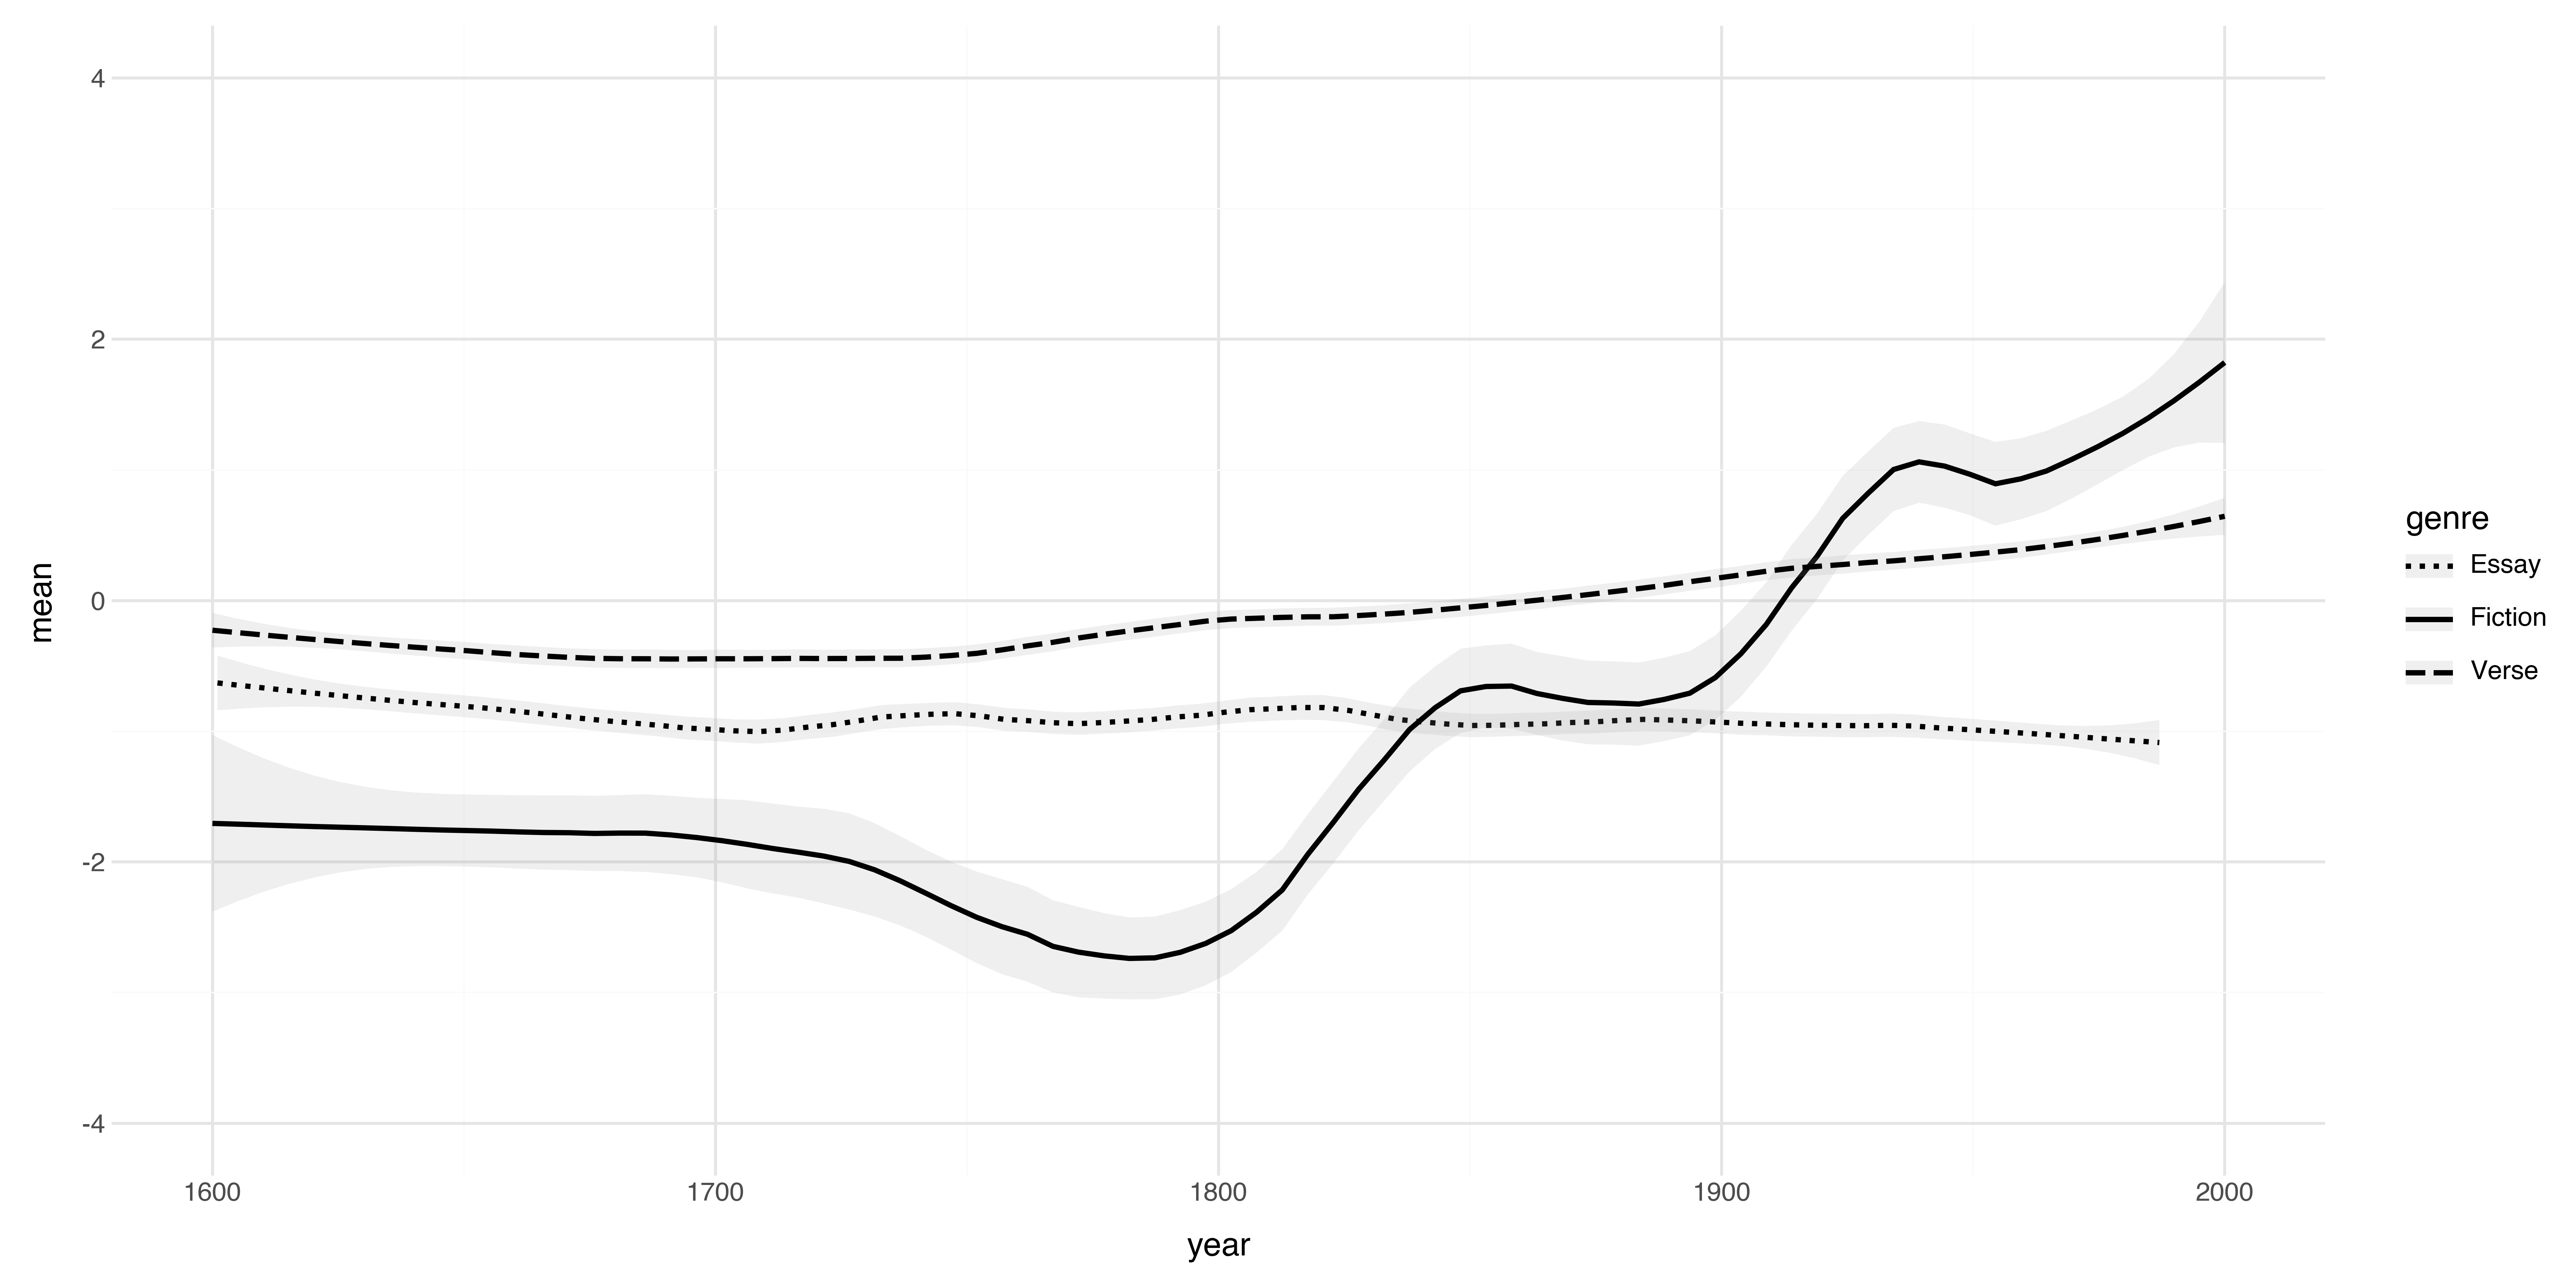

In [121]:
figdf = odf.reset_index().query(f'1600<={yearcol}<=2000')
# figdf = figdf[figdf.genre.isin(genres)]

plot_avgs_df(figdf)

In [101]:
pd.options.display.max_colwidth=1000
df_essay2.sort_values('score', ascending=False)[['score','title']]

,score,title
id,,
K105746.000,0.121036,"An essay concerning the nature of aliments: and the choice of them, according to the different constitutions of human bodies. ... By John Arbuthnot, ..."
K039684.000,0.109322,The mirror. A poetical essay. In the manner of Spenser:
K056602.000,0.030804,"Four essays: viz I. On making china ware in England, ... II. On a method for furnishing coals ... III. On the repairing of Dagenham, ... IV. On our English grapes, ... By a society of gentlemen.:"
K105119.000,0.007054,"An essay concerning the effects of air on human bodies: By John Arbuthnot, ..."
K096396.000,-0.000295,"An essay concerning the outward and salutary application of oils on the human body: By the Rev. William Martin Trinder, MD."
...,...,...
K036080.000,-0.947328,"An essay on the hereditary and indefeasible right of kings. Composed in the year 1745, by Lord Kames:"
K059833.000,-0.947494,Essays on the principles of morality and natural religion: In two parts.
K005472.000,-0.960466,"Human authority, in matters of faith, repugnant to Christianity: illustrated in two discourses on Matth. xxiii. 8. With a prefatory address, ... By the author of An essay on the justice of God."
